<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 210%;text-align: center;border-radius: 10px 70px">
     Retail Sales Analytics and Consumer Behavior 

</center></p></h1>

<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
      Table Content  
</center></p></h1>

-<ul>
  <li><a href="#1">1. Introduction</a></li>



  <li><a href="#">2. Customer Segmentation Using K-Means</a>
    <ul>
      <li><a href="#2.1">2.1. Hopkins Test </a></li>
      <li><a href="#2.2">2.2. Elbow Method (WCSS Plot)</a></li>
      <li><a href="#2.3">2.3. Silhouette Analysis</a></li>
      <li><a href="#2.4">2.4. Applying K-Means Clustering</a></li>
    </ul>
  </li>

  <li><a href="#3">3. Visualization and Insights</a>
  <li><a href="#4">4. DBSCAN clusters</a>
  <li><a href="#5">5. DCompare Kmeans & DBSCAN clusters</a>
  <li><a href="#6">6. Conclusion and Analysis of Customer Segmentation</a></li>
</ul>



<a id="1"></a>
<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
     1. Introduction
</center></p></h1>


<div style="border-radius: 5px;
           font-family: cursive;
           border: 3px solid #008000;
           text-align: justify;
           color: black;
           font-size: 14px;
           padding: 10px;
           background:#F2FFFF;
           line-height:1.7;">

<p style="text-align: center;
          font-family: cursive;
          color: green;
          font-weight: bold;
          font-size: 16px;">
📊 Retail Sales Analytics & Customer Intelligence Platform<br>
<span style="font-size:13px; font-weight:normal;">
From Transactional Data to Data-Driven Business Intelligence
</span>
</p>

<p>
<b>🎯 Business Context</b><br>
Retail organizations generate large volumes of transactional data across customers, products, and sales channels. While this data contains valuable information about customer behavior, sales performance, and profitability, organizations often struggle to transform raw data into actionable business intelligence.
</p>

<p>
Traditional reporting systems focus primarily on operational reporting and provide limited visibility into customer retention, product performance, profitability drivers, and future business opportunities. As a result, decision-makers frequently lack the analytical insights required to support strategic growth.
</p>

<p>
<b>🎯 Project Objective</b><br>
The objective of this project is to develop an end-to-end Retail Sales Analytics and Customer Intelligence Platform that transforms raw supermarket transaction data into actionable business insights.
</p>

<p>
The platform integrates data engineering, SQL analytics, statistical analysis, machine learning, customer analytics, and Power BI reporting to support data-driven decision-making across sales, marketing, inventory management, customer retention, and profitability optimization.
</p>

<p>
<b>📌 Executive Summary</b><br>
This project establishes a comprehensive analytics framework that combines data preparation, exploratory analysis, statistical modeling, customer segmentation, market basket analysis, predictive machine learning, and interactive business intelligence reporting.
</p>

<p>
The analytical workflow uncovers customer behaviors, sales trends, product performance, purchasing patterns, and profitability drivers while generating predictive insights to support strategic business decisions.
</p>

<p>
<b>🚨 Business Problem</b><br>
Despite collecting thousands of daily transactions, the organization lacked a structured framework for converting operational data into meaningful business intelligence.
</p>

<p>
Key business questions included:
</p>

<p>
<b>Customer Analytics</b><br>
• Who are the most valuable customers?<br>
• Which customers are likely to churn?<br>
• What factors influence customer loyalty?
</p>

<p>
<b>Sales & Profitability Analytics</b><br>
• Which products generate the highest revenue and profit?<br>
• How do discounts impact profitability?<br>
• What factors drive revenue growth?
</p>

<p>
<b>Product Intelligence</b><br>
• Which products are frequently purchased together?<br>
• What cross-selling opportunities exist?<br>
• Which categories contribute most to growth?
</p>

<p>
<b>Strategic Business Intelligence</b><br>
• What seasonal patterns affect sales performance?<br>
• Which customer segments should be targeted?<br>
• How can business performance be improved through analytics?
</p>

<p>
The project addresses these challenges by integrating descriptive, diagnostic, and predictive analytics into a unified decision-support platform that converts transactional data into strategic business value.
</p>

</div>



<a id="2.1"></a>
<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
     2.1. Libraries
</center></p></h1>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.preprocessing import StandardScaler, RobustScaler,MinMaxScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import  calinski_harabasz_score, davies_bouldin_score

from sklearn.decomposition import PCA

from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.neighbors import NearestNeighbors

import warnings
warnings.filterwarnings('ignore')

<a id="2.2"></a>
<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
      2.2.Data Loading  
</center></p></h1>

In [ ]:
df = pd.read_excel( 'cleaned_retail_data.xlsx')
df.head()

,Invoice ID,Customer ID,Branch,City,Customer type,Gender,Product line,Unit price (CAD),Quantity,Discount %,...,Revenue,Total_Sales,Total_Cost,Profit,Margin_Percent,Tax_5%,Season,Time_of_Day,Discount_Range,Price_Range
0,635-27-6634,CUST-10010,C,Montreal,Member,Female,Sports and Travel,357.24,14,0.09,...,4551.2376,5001.36,4480.29,70.9476,1.56,227.56188,Winter,Afternoon,0-5%,Medium-High
1,635-27-6634,CUST-10010,C,Montreal,Member,Female,Sports and Travel,357.24,14,0.09,...,4551.2376,5001.36,4480.29,70.9476,1.56,227.56188,Winter,Afternoon,0-5%,Medium-High
2,635-27-6634,CUST-10010,C,Montreal,Member,Female,Sports and Travel,357.24,14,0.09,...,4551.2376,5001.36,4480.29,70.9476,1.56,227.56188,Winter,Afternoon,0-5%,Medium-High
3,635-27-6634,CUST-10010,C,Montreal,Member,Female,Sports and Travel,357.24,14,0.09,...,4551.2376,5001.36,4480.29,70.9476,1.56,227.56188,Winter,Afternoon,0-5%,Medium-High
4,635-27-6634,CUST-10010,C,Montreal,Member,Female,Sports and Travel,357.24,14,0.09,...,4551.2376,5001.36,4480.29,70.9476,1.56,227.56188,Winter,Afternoon,0-5%,Medium-High


<a id="2.10"></a>
<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
    Data split
</div>
</center></p></h1>

In [71]:
df.columns

Index(['Invoice ID', 'Customer ID', 'Branch', 'City', 'Customer type',
       'Gender', 'Product line', 'Unit price (CAD)', 'Quantity', 'Discount %',
       'Payment', 'cogs', 'Rating', 'Customer Satisfaction', 'Loyalty Score',
       'Returned Product', 'Online Order', 'Delivery Time (Days)',
       'Customer Age', 'Age Group', 'Hour', 'Day', 'Weekday', 'Month', 'Year',
       'Weekend', 'Revenue', 'Total_Sales', 'Total_Cost', 'Profit',
       'Margin_Percent', 'Tax_5%', 'Season', 'Time_of_Day', 'Discount_Range',
       'Price_Range'],
      dtype='str')

In [4]:
df['Returned Product'] = df['Returned Product'].map({
    'Yes': 1,
    'No': 0})

df['Online Order'] = df['Online Order'].map({
    'Yes': 1,
    'No': 0})

In [ ]:
customer_df = df.groupby('Customer ID').agg(
    
    # Customer Value
    Total_Revenue=('Revenue','sum'),
    Total_Profit=('Profit','sum'),
    
    # Purchase Behavior
    Total_Orders=('Invoice ID','nunique'),
    Total_Quantity=('Quantity','sum'),
    
    # Customer Experience
    Avg_Rating=('Rating','mean'),
    Avg_Satisfaction=('Customer Satisfaction','mean'),
    Avg_Loyalty=('Loyalty Score','mean'),
    
    # Discount / Return Behavior
    Avg_Discount=('Discount %','mean'),
    Return_Rate=('Returned Product',
                 lambda x: (x=='Yes').mean()),
    
    # Channel Behavior
    Online_Order_Rate=('Online Order',
                       lambda x: (x=='Yes').mean()),
    
    # Demographic
    Customer_Age=('Customer Age','mean')).reset_index()

In [ ]:
customer_df['Avg_Order_Value'] = (
    customer_df['Total_Revenue'] /
    customer_df['Total_Orders'])


customer_df['Profit_per_Order'] = (
    customer_df['Total_Profit'] /
    customer_df['Total_Orders'])

In [47]:
customer_df.shape

(800, 14)

In [48]:
customer_df.isnull().sum()

Customer ID          0
Total_Revenue        0
Total_Profit         0
Total_Orders         0
Total_Quantity       0
Avg_Rating           0
Avg_Satisfaction     0
Avg_Loyalty          0
Avg_Discount         0
Return_Rate          0
Online_Order_Rate    0
Customer_Age         0
Avg_Order_Value      0
Profit_per_Order     0
dtype: int64

In [49]:
features = [
    'Total_Revenue',
    'Total_Profit',
    'Total_Orders',
    'Total_Quantity',
    'Avg_Order_Value',
    'Profit_per_Order',
    'Avg_Discount',
    'Avg_Rating',
    'Avg_Satisfaction',
    'Avg_Loyalty',
    'Return_Rate',
    'Online_Order_Rate',
    'Customer_Age']


X = customer_df[features]

<a id="2.11"></a>
<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
    2.11. Scalling and onhotencoding
</div>
</center></p></h1>

In [51]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Scaled Data shape:", X_scaled.shape)

Scaled Data shape: (800, 13)


In [52]:
X_scaled.mean(axis=0)

array([ 5.99520433e-17,  2.88657986e-17, -8.10462808e-17,  1.26565425e-16,
       -2.79776202e-16,  1.77635684e-16,  1.01030295e-16, -4.41868764e-16,
        5.32907052e-16, -3.91908728e-16,  0.00000000e+00,  0.00000000e+00,
        5.21804822e-17])

In [53]:
X_scaled.std(axis=0)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 1.])

<a id="2.12"></a>
<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
       2.12.PCA & Scaling the DataFrame
</div>
</center></p></h1>

In [64]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(data=X_pca ,columns=["PCA1","PCA2"])
pca_df

,PCA1,PCA2
0,-0.954949,-0.141010
1,2.518847,-1.562001
2,3.006855,-1.323358
3,1.710041,-0.199657
4,-1.491089,0.040743
...,...,...
795,-0.577279,0.784386
796,1.529892,0.211680
797,0.261859,0.472317
798,-2.147516,-0.031093


In [65]:
print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

Explained Variance Ratio: [0.37628117 0.14038147]
Total explained variance: 0.5166626363029329


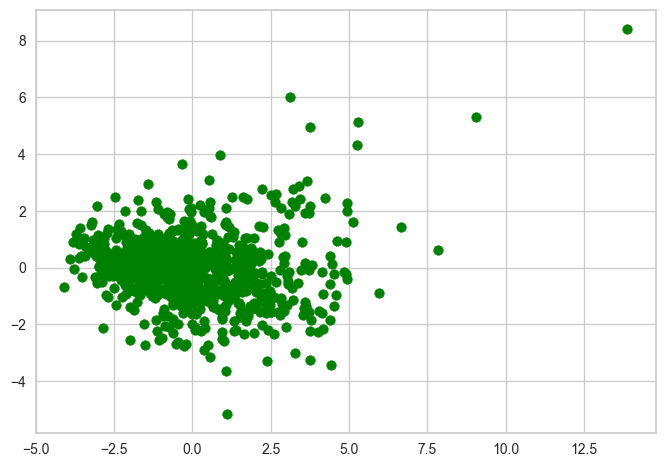

In [66]:
plt.scatter(pca_df['PCA1'],pca_df['PCA2'], color="green")
plt.show()

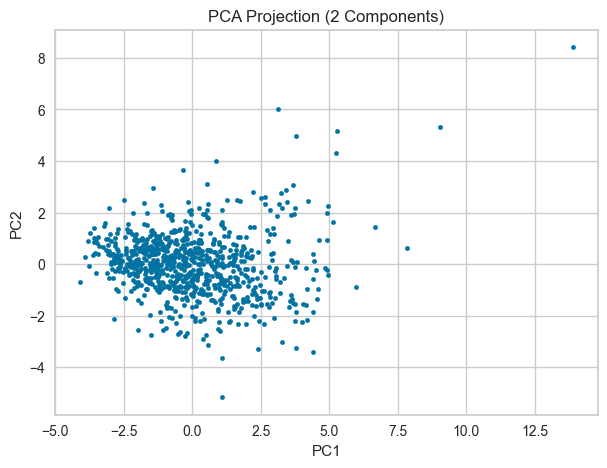

In [67]:
plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=10)
plt.title("PCA Projection (2 Components)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

<a id="3"></a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">3. Customer Segmentation Using K-Means</p>
</div>

<div style="border-radius: 5px;
            -webkit-border-radius: 5px;
            -moz-border-radius: 5px;
            font-family: cursive;
            border: 3px solid #008000;
            text-align: justify;
            color: black;
            font-size: 14px;
            padding: 10px;
            background:#F2FFFF">
    
 <p style="color: green; font-weight: bold; font-size: 16px;">
        K-Means Clustering (Elbow Method + Model Training):
    </p>

<ul style="font-size: 18px; font-family: 'Arial'; line-height: 1.5em;">
        <li>
            To determine the optimal number of clusters, the <b>Within-Cluster Sum of Squares (WCSS)</b> is computed for different values of <b>k</b> using the <b>Elbow Method</b>.
        </li>
        <li>
            The <b>WCSS vs. k</b> plot helps identify the <b>elbow point</b>, which represents a suitable balance between model complexity and clustering performance.
        </li>
        <li>
            Based on the elbow curve, <b>K-Means clustering</b> is applied using the selected number of clusters (e.g., <b>k = 5</b>).
        </li>
        <li>
            The trained K-Means model assigns each customer to a segment, and the cluster labels are stored in a new column named <b>'Cluster'</b> in the RFM dataframe.
        </li>
        <li>
            Finally, cluster sizes are inspected to ensure a reasonable distribution of customers across segments.
        </li>
    </ul>

</div>


![unsupervised](https://databasetown.com/wp-content/uploads/2023/05/Unsupervised-Learning.jpg)
[Credit](https://www.google.com/url?sa=i&url=https%3A%2F%2Fdatabasetown.com%2Funsupervised-learning-types-applications%2F&psig=AOvVaw3OLEBemfakkkUbjtWyb8lc&ust=1700405736787000&source=images&cd=vfe&opi=89978449&ved=0CBQQjhxqFwoTCLiw_5HnzYIDFQAAAAAdAAAAABAD)

<a id="2"></a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px"> K-Means Clustering </p>
</div>

![kmeans](https://editor.analyticsvidhya.com/uploads/56854k%20means%20clustering.png)
[Credit](https://www.google.com/url?sa=i&url=https%3A%2F%2Fwww.analyticsvidhya.com%2Fblog%2F2020%2F10%2Fa-simple-explanation-of-k-means-clustering%2F&psig=AOvVaw3cw8LOufDptpormaHu5Bcf&ust=1700398969640000&source=images&cd=vfe&opi=89978449&ved=0CBQQjhxqFwoTCMiF9P7NzYIDFQAAAAAdAAAAABAD)

<a id="3.1"></a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px"> 3.1.Hopkins Test </p>
</div>

![hopkins](https://i.ytimg.com/vi/E2VAV9eUh1o/maxresdefault.jpg)
[Credit](https://www.google.com/url?sa=i&url=https%3A%2F%2Fwww.youtube.com%2Fwatch%3Fv%3DE2VAV9eUh1o&psig=AOvVaw1dz6u4Y1-sliRNvZ5Z9V58&ust=1700399141138000&source=images&cd=vfe&opi=89978449&ved=0CBQQjhxqFwoTCLiHk83OzYIDFQAAAAAdAAAAABAD)
hopkins : A statistical method that measures data clustering tendency.
More than 0.5 is prone to clustering.

In [54]:
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from random import sample
from numpy.random import uniform




def hopkins(X, sampling_size=0.3):
    """Calculate Hopkins statistic for cluster tendency"""
    X = StandardScaler().fit_transform(X.values) if hasattr(X, 'values') else StandardScaler().fit_transform(X)
    n = X.shape[0]
    d = X.shape[1]
    m = int(sampling_size * n)
    
    # Uniform random samples
    uniform_samples = uniform(np.min(X, axis=0), np.max(X, axis=0), (m, d))
    
    # Random existing samples
    random_indices = sample(range(n), m)
    data_samples = X[random_indices]
    
    # Fit nearest neighbors
    nbrs = NearestNeighbors(n_neighbors=2).fit(X)  # n_neighbors=2 to skip self
    
    # Distances for uniform samples
    u_distances, _ = nbrs.kneighbors(uniform_samples, n_neighbors=1)
    
    # Distances for data samples (skip self)
    w_distances, _ = nbrs.kneighbors(data_samples, n_neighbors=2)
    w_distances = w_distances[:, 1]  # distance to nearest neighbor
    
    H = np.sum(u_distances) / (np.sum(u_distances) + np.sum(w_distances))
    return H

# Calculate Hopkins statistic
hopkins_stat = hopkins(X)
print(f"Hopkins Statistic: {hopkins_stat:.3f}")

Hopkins Statistic: 0.815


In [55]:
def hopkins(X, n_samples=1000):
    """
    Hopkins statistic:
    close to 0.5 => random
    close to 1 => clusterable
    close to 0 => uniform
    """
    if isinstance(X, pd.DataFrame):
        X = X.values

    d = X.shape[1]
    n = X.shape[0]

    if n_samples > n:
        n_samples = n

    np.random.seed(42)

    rand_indices = np.random.choice(range(n), n_samples, replace=False)
    X_sample = X[rand_indices]

    X_min = X.min(axis=0)
    X_max = X.max(axis=0)
    X_random = np.random.uniform(X_min, X_max, (n_samples, d))

    nbrs = NearestNeighbors(n_neighbors=2).fit(X)

    u_dist, _ = nbrs.kneighbors(X_random, n_neighbors=1)
    w_dist, _ = nbrs.kneighbors(X_sample, n_neighbors=2)

    u_sum = np.sum(u_dist)
    w_sum = np.sum(w_dist[:, 1])

    H = u_sum / (u_sum + w_sum)
    return H

H_score = hopkins(X_scaled, n_samples=1000)
print("\nHopkins Statistic:", H_score)


Hopkins Statistic: 0.8116339168619522



<div style="border-radius: 12px;
     -webkit-border-radius: 12px;
     -moz-border-radius: 12px;
     font-family: cursive;
     border: 3px solid #007A33;
     background: #F6FFF9;
     color: black;
     font-size: 15px;
     padding: 18px;
     line-height: 1.7;">

  <p style="font-weight: bold; color:rgb(20, 1, 1); font-size: 18px; margin-top:0;">
    📌 Hopkins Statistic for Clusterability
  </p>

  <p>The computed <b>Hopkins statistic</b> is: <b>{0.835:.4f}</b></p>

  <ul style="margin: 0; padding-left: 22px;">
    <li><b>Interpretation:</b></li>
    <ul style="list-style-type: circle; padding-left: 20px;">
      <li>Value close to <b>0.5</b> → data is randomly distributed (not clusterable).</li>
      <li>Value close to <b>1.0</b> → data has a high tendency to form clusters (clusterable).</li>
      <li>Value close to <b>0</b> → data is uniformly distributed (no clusters).</li>
    </ul>
    <li>Since the Hopkins statistic is <b>0.811</b>, it indicates the dataset is highly <b>clusterable</b> and suitable for clustering methods like <b>KMeans</b> or <b>DBSCAN</b>.</li>
  </ul>

</div>
"""))


<a id="3.2"><a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px"> 3.2.Choosing The Optimal Number of Clusters-Elbow Method  </p>
</div>

![elbow](https://miro.medium.com/v2/resize:fit:1340/1*RnvrdhlUxHWss3vOffHT5g.png)
[Credit](https://www.google.com/url?sa=i&url=https%3A%2F%2Fmedium.com%2Fmlearning-ai%2Felbow-method-vs-silhouette-co-efficient-in-determining-the-number-of-clusters-33baff2fbeee&psig=AOvVaw13SYCkS-Yd2NZS_TZHA0B1&ust=1700399312464000&source=images&cd=vfe&opi=89978449&ved=0CBMQjhxqFwoTCLjasZvPzYIDFQAAAAAdAAAAABAI)

In [56]:
inertias = []
K_range = range(2, 11)



In [57]:
# K-Means Clustering
# Determine optimal number of clusters using Elbow Method
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)


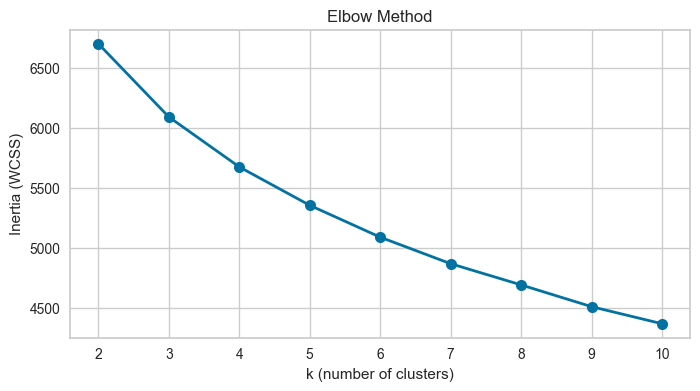

In [58]:
plt.figure(figsize=(8, 4))
plt.plot(list(K_range), inertias, marker="o", linewidth=2, markersize=8)
plt.xlabel("k (number of clusters)")
plt.ylabel("Inertia (WCSS)")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

<div style="border-radius: 5px;
     -webkit-border-radius: 5px;
     -moz-border-radius: 5px;
     font-family: cursive;
     border: 3px solid #007A33;
     background: #F6FFF9;
     color: black;
     font-size: 14px;
     padding: 15px;">
     
<p style="font-weight: bold; color: black;">An elbow is observed at 2
, indicating a point of inflection. According to the elbow graph, selecting a higher number of clusters increases complexity. Therefore, it is more suitable to choose 4 clusters in this case.</p>
</div>

<a id="3.3"><a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px"> 3.3.Silhouette Analysis</p>
</div>

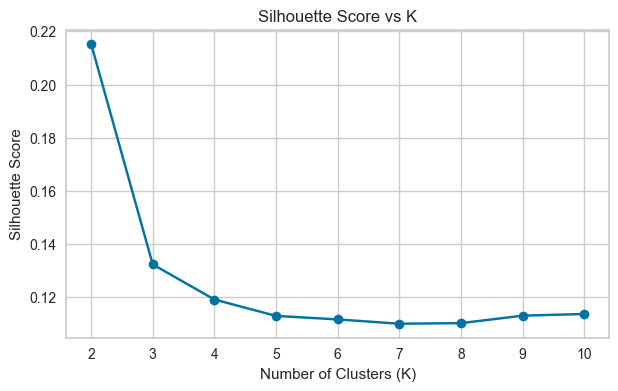


Best K (Silhouette): 2


In [59]:

K_range = range(2, 11)
sil_scores = []


for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    sil_scores.append(sil)

plt.figure(figsize=(7, 4))
plt.plot(list(K_range), sil_scores, marker="o")
plt.title("Silhouette Score vs K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.show()

best_k = K_range[np.argmax(sil_scores)]
print("\nBest K (Silhouette):", best_k)



<div style="border-radius: 5px;
     -webkit-border-radius: 5px;
     -moz-border-radius: 5px;
     font-family: cursive;
     border: 3px solid #007A33;
     background: #F6FFF9;
     color: black;
     font-size: 14px;
     padding: 15px;">
     <p style="font-weight: bold; color: black;">While examining silhouette scores, it is noted that the scores are relatively close to each other. However, when considered in conjunction with the elbow method, a cluster count of 4 appears to be suitable. It's worth mentioning that the silhouette score considers both intra-cluster and inter-cluster distances, aiming for a value close to 1 for better clustering results.</p>
</div>

<a id="3.4"></a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px"> 3.4. Applying K-Means Clustering
</p>
</div>

In [60]:

#  Fit KMeans
n_clusters = 2
kmeans_model = KMeans(n_clusters=n_clusters, random_state=42)
kmeans_labels = kmeans_model.fit_predict(X_scaled)

#  Add cluster labels to PCA dataframe for visualization
customer_df['Cluster'] = kmeans_labels


In [61]:
customer_df['Cluster'].value_counts()

Cluster
0    501
1    299
Name: count, dtype: int64

In [68]:

#  Fit KMeans
n_clusters = 2
kmeans_model = KMeans(n_clusters=n_clusters, random_state=42)
kmeans_labels = kmeans_model.fit_predict(X_scaled)

#  Add cluster labels to PCA dataframe for visualization
pca_df['Cluster'] = customer_df['Cluster']



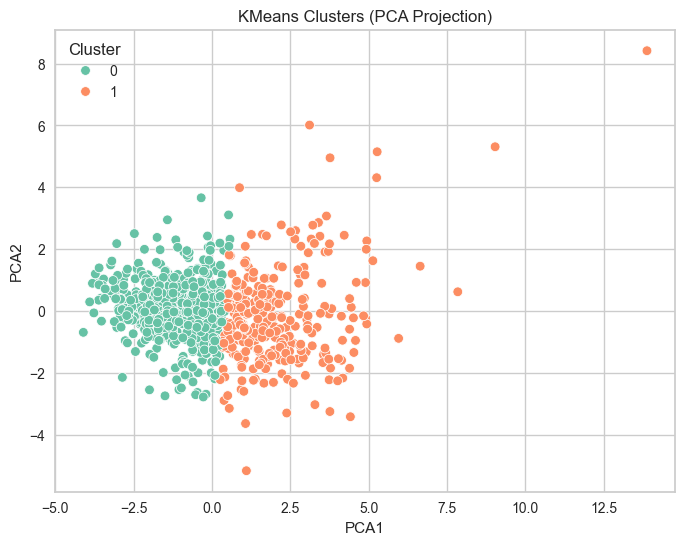

In [69]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, x='PCA1', y='PCA2', hue='Cluster', palette='Set2')
plt.title("KMeans Clusters (PCA Projection)")
plt.show()

In [ ]:
features = [
    'Total_Revenue',
    'Total_Profit',
    'Total_Orders',
    'Total_Quantity',
    'Avg_Order_Value',
    'Profit_per_Order',
    'Avg_Discount',
    'Avg_Rating',
    'Avg_Satisfaction',
    'Avg_Loyalty',
    'Return_Rate',
    'Online_Order_Rate',
    'Customer_Age']

In [77]:
cluster_profile = (
    customer_df
    .groupby('Cluster')[features]
    .mean()
    .round(2))


cluster_profile

,Total_Revenue,Total_Profit,Total_Orders,Total_Quantity,Avg_Order_Value,Profit_per_Order,Avg_Discount,Avg_Rating,Avg_Satisfaction,Avg_Loyalty,Return_Rate,Online_Order_Rate,Customer_Age
Cluster,,,,,,,,,,,,,
0,233273.13,19289.65,11.42,915.00,19932.67,1772.69,0.1,4.04,70.65,49.70,0.0,0.0,43.44
1,553842.96,77135.88,16.77,1961.92,32981.01,4784.87,0.1,4.02,69.97,49.99,0.0,0.0,43.18


<a id="4"></a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">4. Visualization and Insights </p>
</div>

<div style="border-radius: 5px;
            -webkit-border-radius: 5px;
            -moz-border-radius: 5px;
            font-family: cursive;
            border: 3px solid #008000;
            text-align: justify;
            color: black;
            font-size: 14px;
            padding: 10px;
            background:#F2FFFF">
    
 <p style="color: green; font-weight: bold; font-size: 16px;">
        Visualization and Insights:
    </p>

  <ul style="font-size: 18px; font-family: 'Arial'; line-height: 1.5em;">
        <li>
            <b>Pairplot:</b> Visualizes relationships between the <b>scaled RFM features</b> colored by cluster labels,
            helping observe how well clusters separate across <b>Recency</b>, <b>Frequency</b>, and <b>Monetary</b>.
        </li>
        <li>
            <b>Scatter Plot (Recency vs. Monetary):</b> Displays customer segments using <b>Recency</b> and <b>Monetary</b> values,
            where different colors represent cluster assignments.
        </li>
        <li>
            <b>Customer Segments by PCA:</b> Applies <b>Principal Component Analysis (PCA)</b> to reduce the scaled RFM features into
            <b>two principal components</b>, enabling a clearer 2D visualization of cluster separation.
        </li>
        <li>
            <b>Cluster Profiling:</b> Summarizes customer segments by reporting the <b>average Recency, Frequency, and Monetary</b>
            values per cluster, supporting interpretation of each segment’s behavior and characteristics.
        </li>
    </ul>

</div>


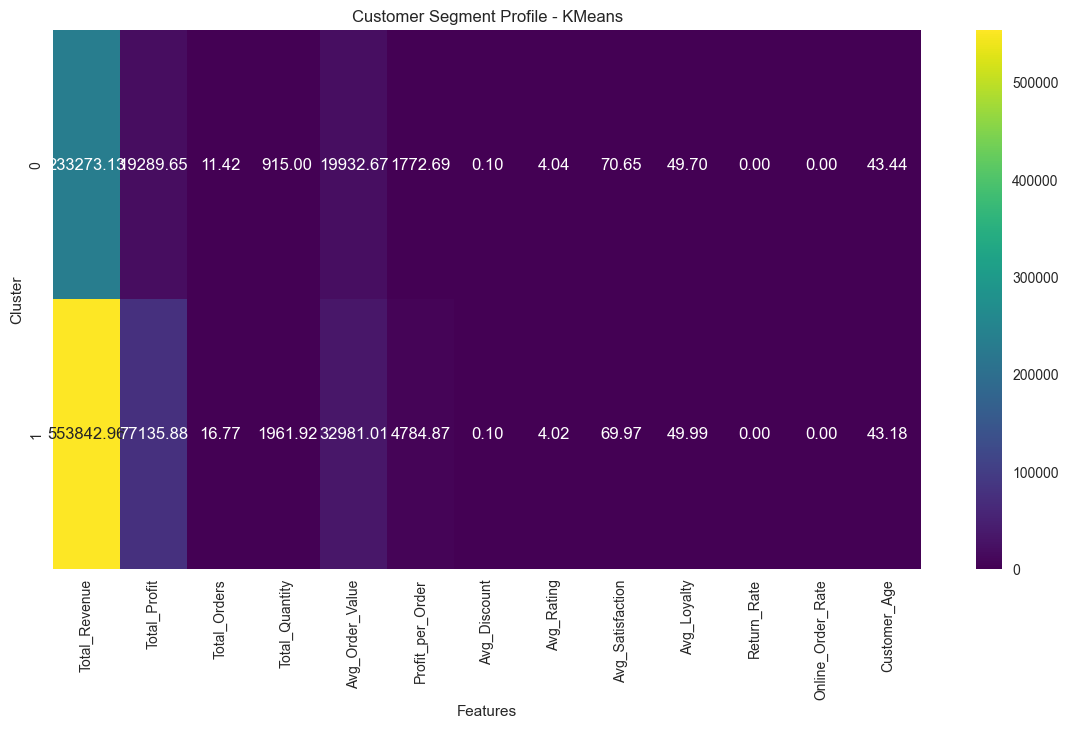

In [78]:


plt.figure(figsize=(14,7))

sns.heatmap(
    cluster_profile,
    annot=True,
    fmt='.2f',
    cmap='viridis')

plt.title('Customer Segment Profile - KMeans')
plt.xlabel('Features')
plt.ylabel('Cluster')

plt.show()

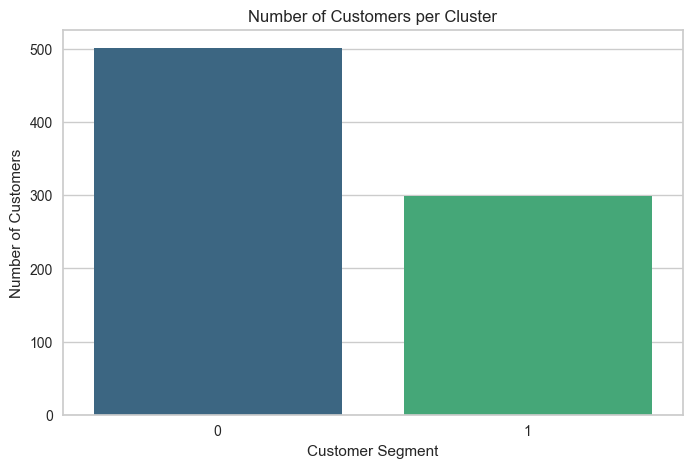

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=customer_df,
    x='Cluster',
    palette='viridis')

plt.title('Number of Customers per Cluster')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')

plt.show()

In [22]:
pca_df['Cluster'].value_counts()

Cluster
0    512
1    288
Name: count, dtype: int64

In [ ]:
fig = px.scatter_3d(
    pca_df,
    x='PCA1',
    y='PCA2',
    z='Cluster',
    color='Cluster',
    title='K-Means Customer Segmentation (PCA)')

fig.update_traces(
    marker=dict(size=6))

fig.show()

<div style="border-radius: 5px;
     -webkit-border-radius: 5px;
     -moz-border-radius: 5px;
     font-family: cursive;
     border: 3px solid #007A33;
     background: #F6FFF9;
     color: black;
     font-size: 14px;
     padding: 15px;">
     <p style="font-weight: bold; color: black;">When examined in three dimensions, data points become more distinguishable according to clusters.</p>
</div>


Text(0.5, 1.0, 'Distribution of clusters')

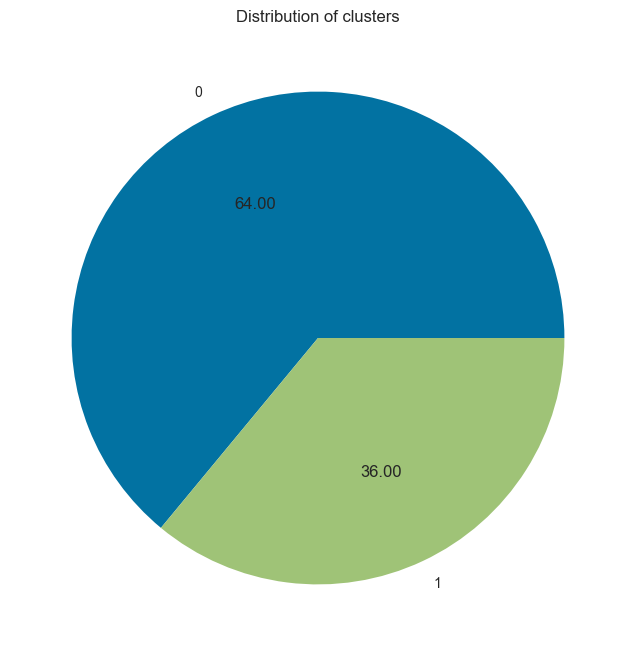

In [28]:
pca_df['Cluster'].value_counts().plot(kind="pie", autopct='%.2f', figsize=[8,8], label="")
plt.title('Distribution of clusters')

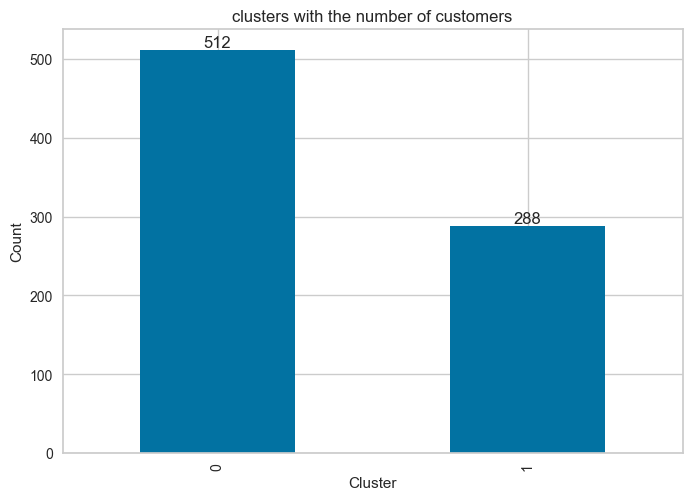

In [30]:
plt.title("clusters with the number of customers")
plt.xlabel("clusters")
plt.ylabel("Count")
ax = pca_df['Cluster'].value_counts().plot(kind='bar')
ax.bar_label(ax.containers[0])
plt.show()

<div style="border-radius: 5px;
     -webkit-border-radius: 5px;
     -moz-border-radius: 5px;
     font-family: cursive;
     border: 3px solid #007A33;
     background: #F6FFF9;
     color: black;
     font-size: 14px;
     padding: 15px;">
    <ul style="font-weight: bold; color: black; margin: 0; padding-left: 20px;">
        <li>It is observed that the highest number of individuals is in Cluster 0, while the lowest number is in Cluster 1.</li>
    </ul>
</div>

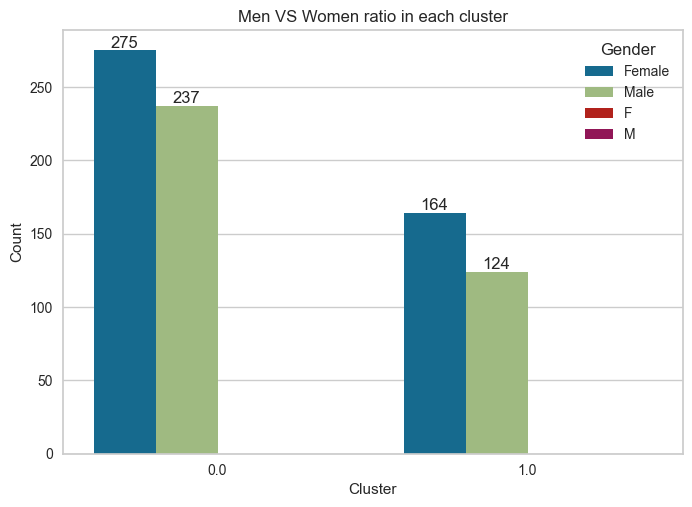

In [35]:
plt.title("Men VS Women ratio in each cluster")
plt.ylabel("Count")
ax = sns.countplot(x=pca_df['Cluster'], hue=df['Gender'])
for p in ax.containers:
    ax.bar_label(p)
plt.show()

<div style="border-radius: 5px;
     -webkit-border-radius: 5px;
     -moz-border-radius: 5px;
     font-family: cursive;
     border: 3px solid #007A33;
     background: #F6FFF9;
     color: black;
     font-size: 14px;
     padding: 15px;">
    <ul style="font-weight: bold; color: black; margin: 0; padding-left: 20px;">
        <li>Except for Cluster 0, the number of females is higher than males in the other clusters</li>
    </ul>
</div>

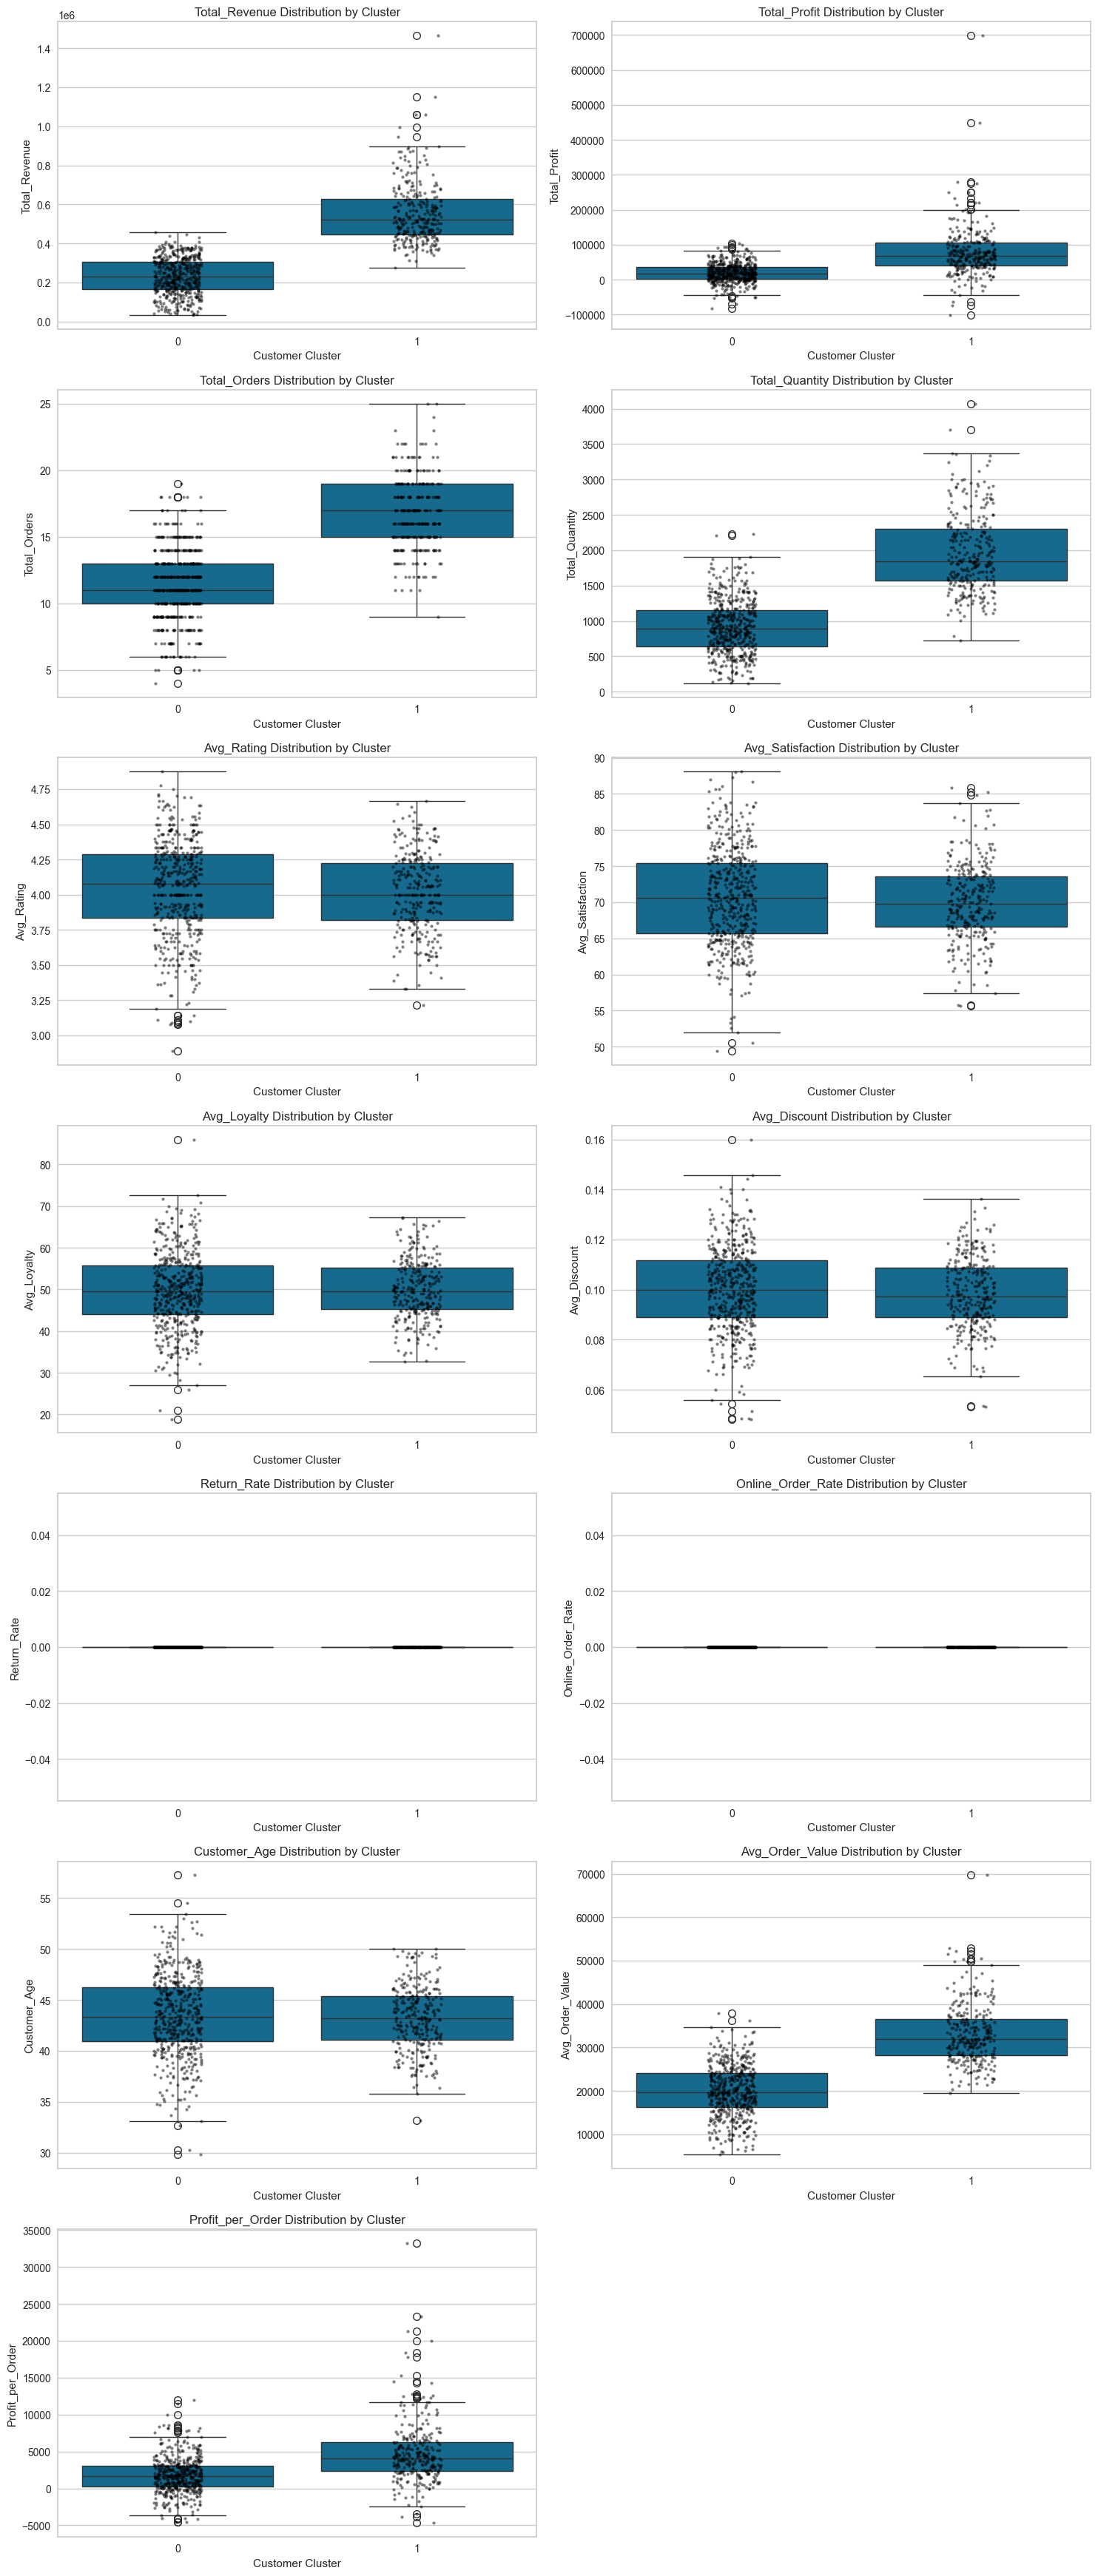

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical features except Cluster
numeric_columns = (
    customer_df
    .drop(['Cluster', 'Customer ID'], axis=1)
    .select_dtypes(include='number')
    .columns
)


num_plots = len(numeric_columns)

num_cols = 2

num_rows = (num_plots + num_cols - 1) // num_cols


plt.figure(figsize=(15, num_rows * 5))


for i, feature in enumerate(numeric_columns):

    plt.subplot(num_rows, num_cols, i + 1)

    sns.boxplot(
        data=customer_df,
        x='Cluster',
        y=feature)

    sns.stripplot(
        data=customer_df,
        x='Cluster',
        y=feature,
        color='black',
        size=3,
        alpha=0.5)

    plt.title(f'{feature} Distribution by Cluster')
    plt.xlabel('Customer Cluster')
    plt.ylabel(feature)


plt.tight_layout()
plt.show()

<div style="border-radius: 5px;
     -webkit-border-radius: 5px;
     -moz-border-radius: 5px;
     font-family: cursive;
     border: 3px solid #007A33;
     background: #F6FFF9;
     color: black;
     font-size: 14px;
     padding: 15px;">
    <ul style="color: black; font-weight: bold;">
        <li>In Cluster 0, individuals are observed to have moderate to low ages, moderate incomes, and moderate scores. Encouraging increased spending for this cluster could be beneficial.</li>
        <li>Cluster 1 comprises individuals with moderate ages, low to moderate incomes, and the highest scores. Despite their high spending, it may be noted that the revenue generated by this cluster is relatively low.</li>
        <li>Cluster 2 consists of individuals with moderate ages, low to moderate incomes, and the lowest scores. Campaigns targeting this cluster could potentially increase their spending.</li>
        <li>In Cluster 3, individuals are of moderate to older ages, with moderate incomes and scores. Various campaigns could be designed to boost spending for this group.</li>
    </ul>
</div>

<Figure size 2000x1000 with 0 Axes>

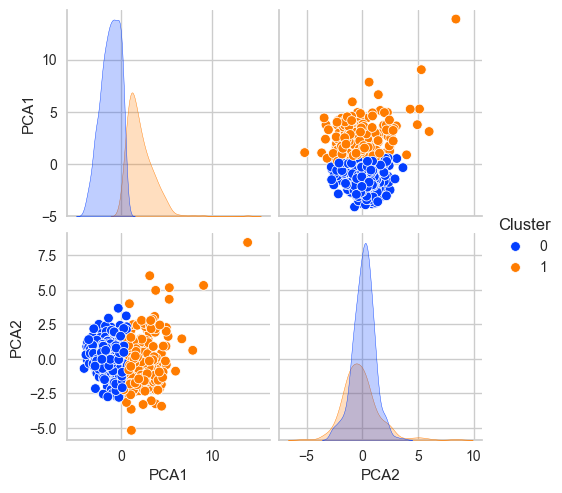

In [83]:
plt.figure(figsize=(20,10))
sns.pairplot(data=pca_df, hue="Cluster", palette="bright")

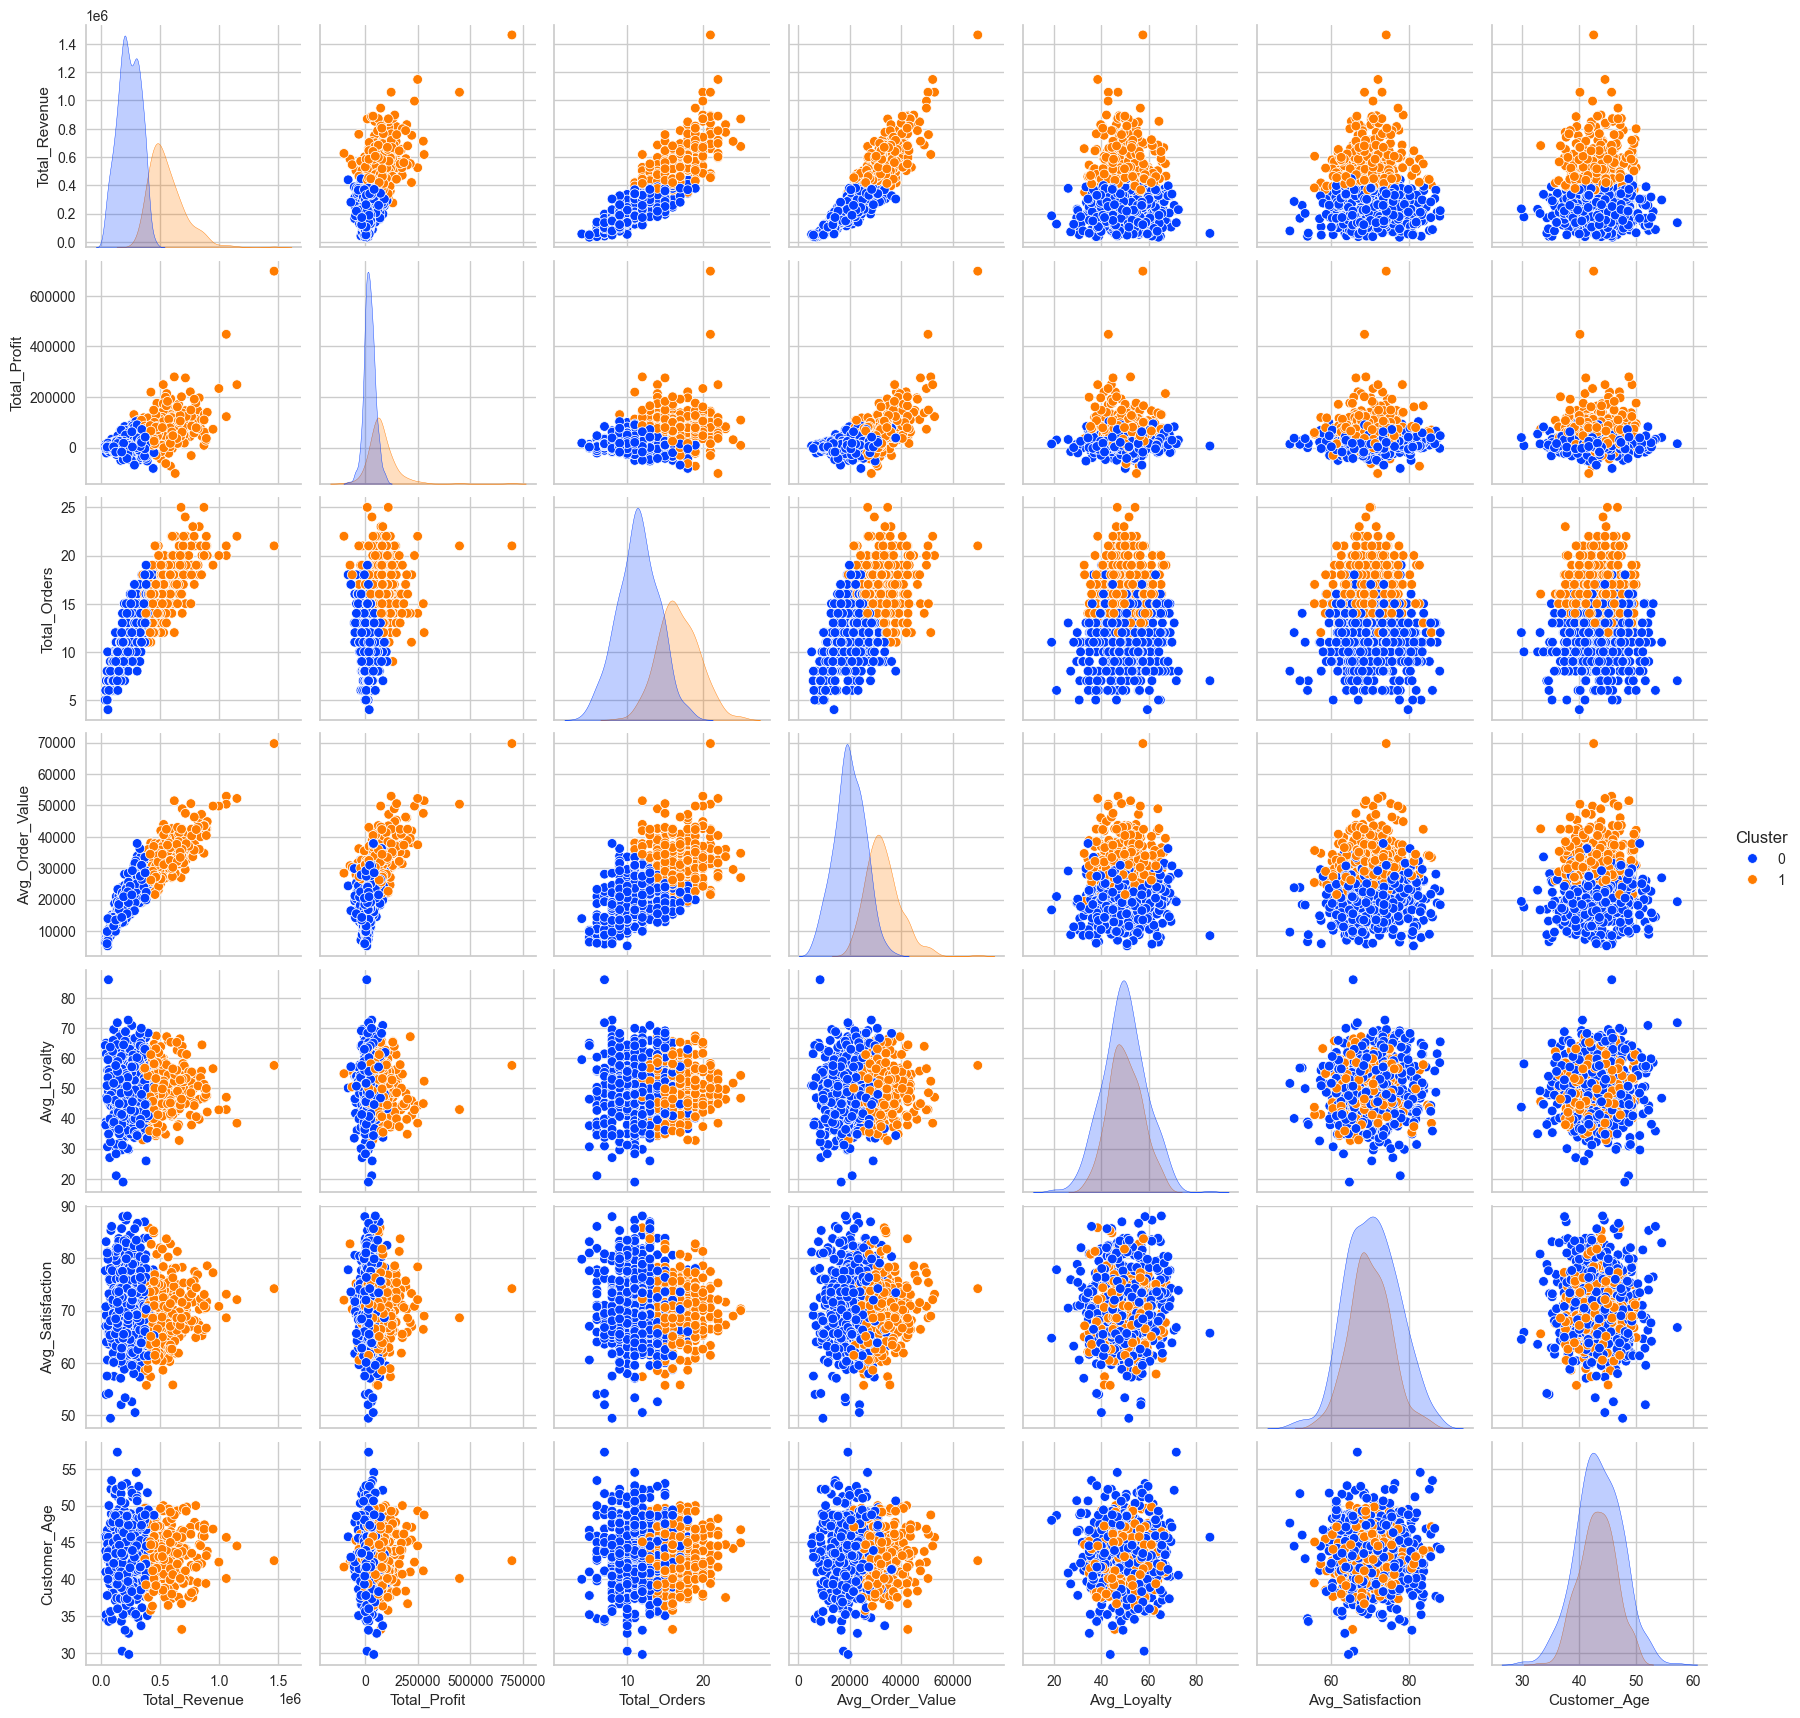

In [ ]:
numeric_features = [
    'Total_Revenue',
    'Total_Profit',
    'Total_Orders',
    'Avg_Order_Value',
    'Avg_Loyalty',
    'Avg_Satisfaction',
    'Customer_Age']


sns.pairplot(
    customer_df[numeric_features + ['Cluster']],
    hue='Cluster',
    palette='bright',
    diag_kind='kde',
    height=2.5)

plt.show()

### Customer Segments by PCA

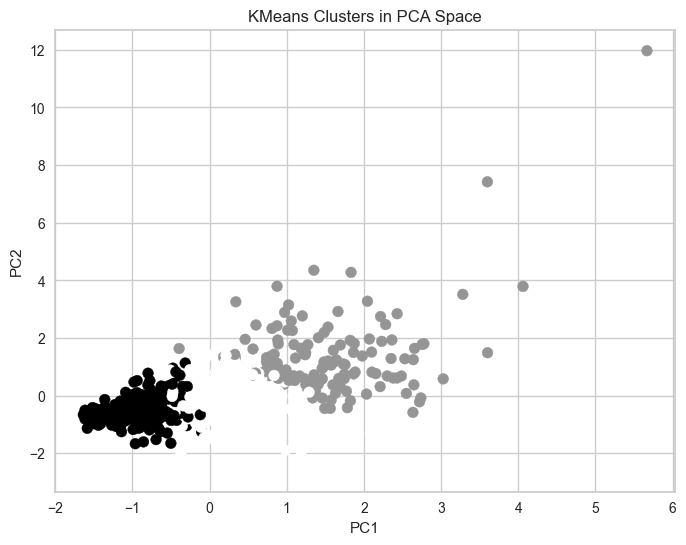

In [84]:
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X_scaled)
    
    # Now you can run your plot
    plt.figure(figsize=(8, 6))
    plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters, s=60)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("KMeans Clusters in PCA Space")
    plt.grid(True)
    plt.show()

<div style="border-radius: 5px; -webkit-border-radius: 5px; -moz-border-radius: 5px; font-family: cursive; border: 3px solid #007A33; background: #F6FFF9; color: black; font-size: 14px; padding: 15px;"> <ul style="color: black; font-weight: bold;"> <li>❌ PCA was applied to the wrong dataframe (for example, empty dataframe or only Cluster column).</li> <li>❌ The features used for PCA have no variance (all values are identical).</li> <li>❌ PCA was performed before scaling the K-Means features.</li> <li>❌ You accidentally created PCA from cluster labels instead of customer features.</li> <li>❌ The PCA dataframe was overwritten and lost the original values.</li> </ul> </div>

<a id="7"></a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px"> 7.ConcConclusion and Analysis of Customer Segmentationlusion</p>
</div>

<div style="border-radius: 5px;
     -webkit-border-radius: 5px;
     -moz-border-radius: 5px;
     font-family: cursive;
     border: 3px solid #007A33;
     background: #F6FFF9;
     color: black;
     font-size: 14px;
     padding: 15px;">
    <ul style="color: black; font-weight: bold;">
        li><strong>Age-Spending-Score:</strong> K-means clustering with 4 clusters provided effective segmentation.</li>
        <li><strong>Income-Spending-Score:</strong> Hierarchical clustering with 5 clusters demonstrated successful results.</li>
        <li><strong>Cluster Distributions:</strong> Some graphs, such as gender-based cluster distributions, exhibited similarities.</li>
        <li><strong>Graph Variances:</strong> Differences were observed in other graphs, emphasizing the need for tailored interpretations.</li>
        <li><strong>Cluster Analysis:</strong> Box plots and bar plots of clusters were scrutinized to convey insights.</li>
        <li><strong>Cluster Selection:</strong> The choice of the number of clusters depends on the nature of the problem, expert opinions, and interpretability.</li>
       
</ul>
</div>